<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [98]:
versuchsnummer = "251"
versuchsname = "statistik_Radioaktivitaet" 
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [99]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

In [ ]:
# Messdaten
U_0 = 570
U_1 = U_0 + 100

# Spannung U_0
min1_U0 = 5266 # n0_1
min3_U0 = 15349 # n1_3

err_min1_U0 = sqrt(5266) 
err_min3_U0 = sqrt(15349)

# Spannung U_1
min1_U1 = 5175 # n0_1
min3_U1 = 15388 # n1_3

err_min1_U1 = sqrt(5175)
err_min3_U1 = sqrt(15388)

In [ ]:
# Bestimmung der Differenz D
D_min1 = np.abs(min1_U0 - min1_U1)
D_min3 = np.abs(min3_U0 - min3_U1)

err_D_min1 = sqrt(err_min1_U0**2 + err_min1_U1**2)
err_D_min3 = sqrt(err_min3_U0**2 + err_min3_U1**2)

print(fr'Die Differenz für eine Minute beträgt: {pap.round_sig_digs(err_D_min1, D_min1)[2]}')
print(fr'Die Differenz für drei Minuten beträgt: {pap.round_sig_digs(err_D_min3, D_min3)[2]}')

Die Abweichung für eine Minute beträgt: 90 \pm 100
Die Abweichung für drei Minuten beträgt: 40 \pm 180


In [137]:
# Bestimmung des Signifikanznieaus
sig_niv_min1 = D_min1/err_D_min1
sig_niv_min3 = D_min3/err_D_min3

print(fr'Das Signifikanzniveau für eine Minute beträgt: {sig_niv_min1:.2f}')
print(fr'Das Signifikanzniveau für drei Minuten beträgt: {sig_niv_min3:.2f}')

Das Signifikanzniveau für eine Minute beträgt: 0.89
Das Signifikanzniveau für drei Minuten beträgt: 0.22


In [170]:
# Prozentuale Abweichung
prozAbw_min1 = min1_U0/min1_U1
prozAbw_min3 = min3_U0/min3_U1

n0, n1 = sp.symbols(r'{n_0}, {n_1}')

func = n0/n1

values = np.column_stack([
    [min1_U0, min3_U0], [err_min1_U0, err_min3_U0], 
    [min1_U1, min3_U1], [err_min1_U1, err_min3_U1], 
])

temp = pap.do_it(func, [n0, n1], values, [], True)

prozAbw_min1 = temp[0][0]
err_prozAbw_min1 = temp[0][1]

prozAbw_min3 = temp[1][0]
err_prozAbw_min3 = temp[1][1]

print(f'Die prozentuale Abweichung für die Messzeit von einer Minute:\n({pap.round_sig_digs(err_prozAbw_min1, prozAbw_min1)[2]})%\n')
print(f'Die prozentuale Abweichung für die Messzeit von drei Minuten:\n({pap.round_sig_digs(err_prozAbw_min3, prozAbw_min3)[2]})%')


gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Die prozentuale Abweichung für die Messzeit von einer Minute:
(1.018 \pm 0.020)%

Die prozentuale Abweichung für die Messzeit von drei Minuten:
(0.997 \pm 0.011)%


<hr>

## Aufgabe 1

In [100]:
# Messdaten
# Zälrohrspannung
U = np.array([480, 505, 530, 555, 580, 605, 630])
err_U = 10

# Ereignisse
N = np.array([2032, 2531, 2472, 2543, 2561, 2545, 2522])
err_N = np.sqrt(N)

In [101]:
def linear(x, a, b):
    return a * x + b

In [102]:
popt, pcov = curve_fit(linear, U[1:], N[1:])

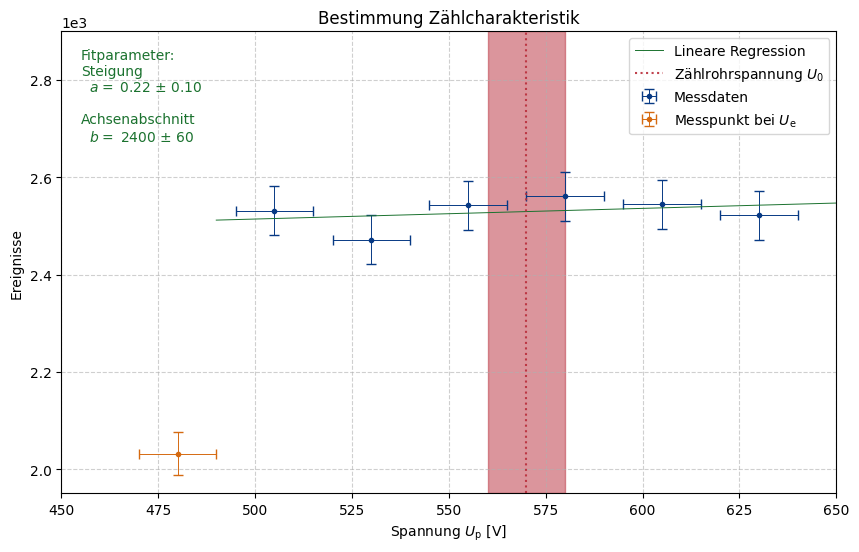

<Axes: title={'center': 'Bestimmung Zählcharakteristik'}, xlabel='Spannung $U_\\text{p}$ [V]', ylabel='Ereignisse'>

In [208]:
aufgabe = '1a'

plt.figure(figsize = (10, 6))

plt.errorbar(
    U[1:],
    N[1:], 
    err_N[1:],
    err_U, 
    fmt = '.', 
    capsize=3.5, 
    label='Messdaten',
    color=c.BLUE,
    linewidth=0.7
    )

plt.errorbar(
    U[0],
    N[0], 
    err_N[0],
    err_U, 
    fmt = '.', 
    capsize=3.5, 
    label=r'Messpunkt bei $U_\text{e}$',
    color=c.ORANGE,
    linewidth=0.7
    )

plt.ylim(1950,2900)
plt.xlim(450,650)


# Regression

U_test = np.linspace(490, 650, 100)

plt.plot(
    U_test, 
    linear(U_test, *popt), 
    label='Lineare Regression',
    linewidth=0.7,
    color=c.GREEN
    )

plt.text(455, 2.675e3, 
        'Fitparameter:\n' 
        + f'Steigung\n  $a = $ {pap.round_sig_digs(pcov[0,0], popt[0])[3]} \n\n'
        + f'Achsenabschnitt\n  $b = $ {pap.round_sig_digs(pcov[0,1], popt[1])[3]}',
        color=c.GREEN
        )

pap.plot_errorlines(plt.gca(), [570], 10, 1.95e3, 2.9e3, label='Zählrohrspannung $U_0$', add_label=True)

pap.plot_me('Bestimmung Zählcharakteristik', r'Spannung $U_\text{p}$ [V]', 'Ereignisse', fr'{plt_save_folder}Platau_{aufgabe}')

<hr>

## Aufgabe 2

In [ ]:
data_file = 'A2.txt'

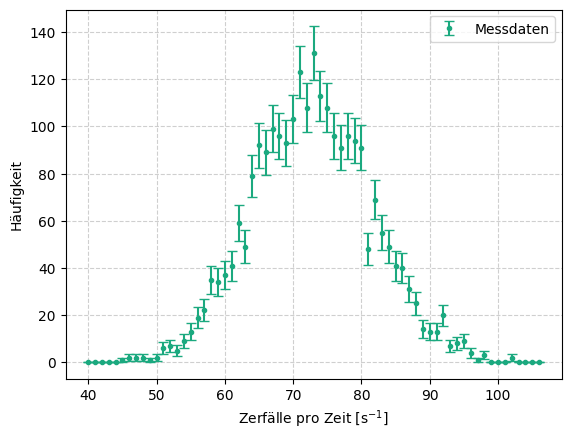

<Axes: xlabel='Zerfälle pro Zeit [$\\mathrm{s^{-1}}$]', ylabel='Häufigkeit'>

In [ ]:
aufgabe = '2a'

decays, counts = np.loadtxt(data_file, unpack=True, delimiter=',', skiprows=4)
err_counts = np.sqrt(counts)


plt.errorbar(
    decays, 
    counts, 
    err_counts,
    fmt='.',
    capsize=3.5,
    label='Messdaten'
    )

pap.plot_me('', r'Zerfälle pro Zeit [$\mathrm{s^{-1}}$]', 'Häufigkeit', f'{plt_save_folder}histo{aufgabe}')

In [ ]:
def gaussian(x, A, mu, sig): #A: Flaeche der Gaussfunktion
    return A / (sqrt(2 * pi) * sig) * exp( - (x - mu) ** 2 / 2 / sig ** 2)

In [268]:
leftBound = 5
rightBound = 8

In [269]:
# Gauss fit
popt_gau, pcov_gau = curve_fit(gaussian, decays[leftBound:-rightBound], counts[leftBound:-rightBound],
p0 = [2000, 72, 8], sigma = err_counts[leftBound:-rightBound])

In [270]:
# Poisson-Verteilung
from scipy.special import gamma
def poisson(x, A_p, mu_p):
    return A_p * exp(-mu_p) * mu_p ** x / gamma(x + 1)

In [271]:
# Possion fit
popt_pos, pcov_pos = curve_fit(poisson, decays[leftBound:-rightBound], counts[leftBound:-rightBound],
p0 = [2000, 72], sigma = err_counts[leftBound:-rightBound])

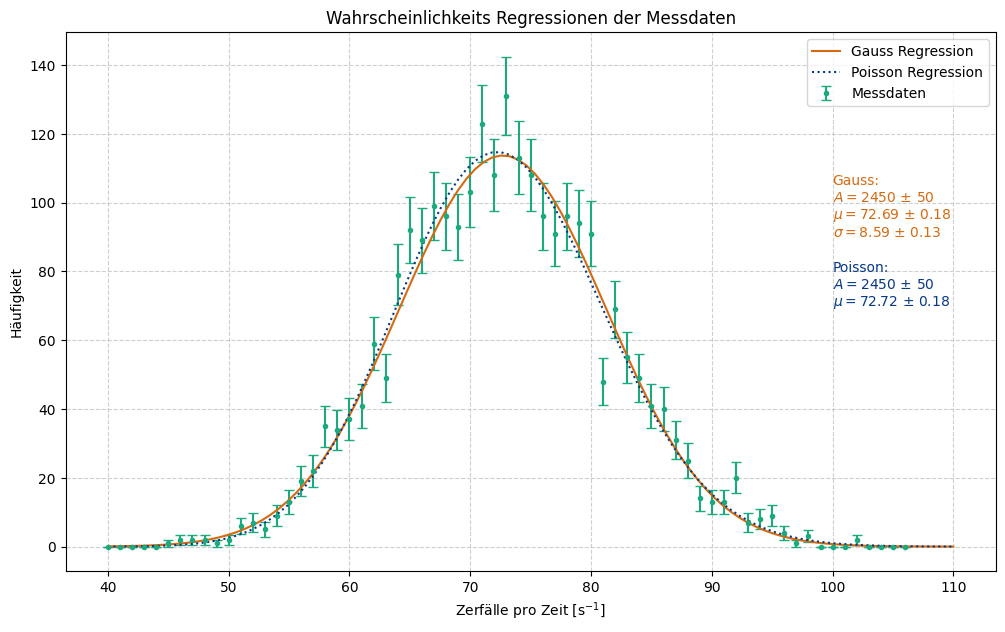

<Axes: title={'center': 'Wahrscheinlichkeits Regressionen der Messdaten'}, xlabel='Zerfälle pro Zeit [$\\mathrm{s^{-1}}$]', ylabel='Häufigkeit'>

In [272]:
aufgabe = '2b'

plt.figure(figsize = (12, 7))

plt.errorbar(
    decays, 
    counts, 
    err_counts,
    fmt='.',
    capsize=3.5,
    label='Messdaten'
    )

# Regressions Funktionen
x = np.linspace(40, 110, 100)
plt.plot(
    x, 
    gaussian(x, *popt_gau), 
    label = 'Gauss Regression'
    )

plt.plot(
    x, 
    poisson(x, *popt_pos), 
    label = 'Poisson Regression',
    linestyle = ':'
    )


plt.text(100,90, 
        'Gauss:\n$A=$' 
        + pap.round_sig_digs(sqrt(pcov_gau[0][0]), popt_gau[0])[3] 
        + '\n' + r'$\mu=$'
        + pap.round_sig_digs(sqrt(pcov_gau[1][1]), popt_gau[1])[3] 
        + '\n' + r'$\sigma=$'
        + pap.round_sig_digs(sqrt(pcov_gau[2][2]), popt_gau[2])[3],
        color=c.ORANGE
        )

plt.text(100,70, 
        'Poisson:\n$A=$' 
        + pap.round_sig_digs(sqrt(pcov_pos[0][0]), popt_pos[0])[3] 
        + '\n' + r'$\mu=$'
        + pap.round_sig_digs(sqrt(pcov_pos[1][1]), popt_pos[1])[3],
        color=c.BLUE
        )

pap.plot_me('Wahrscheinlichkeits Regressionen der Messdaten', r'Zerfälle pro Zeit [$\mathrm{s^{-1}}$]', 'Häufigkeit', f'{plt_save_folder}histo{aufgabe}')

In [287]:
#Gauss:
chi2_gau = np.sum((gaussian(decays[leftBound:-rightBound], *popt_gau) - counts[leftBound:-rightBound]) ** 2 /
err_counts[leftBound:-rightBound] ** 2)
dof_gau = len(decays[leftBound:-rightBound]) - 3 # 3 Parameter (dof: Degree of Freedom)
chi2_red_gau = chi2_gau / dof_gau
print("chi2_g=", chi2_gau)
print("chi2_red_g=",chi2_red_gau)

#Poisson:
chi2_pos = np.sum((poisson(decays[leftBound:-rightBound], *popt_pos) - counts[leftBound:-rightBound]) ** 2 /
err_counts[leftBound:-rightBound] ** 2)
dof_pos = len(decays[leftBound:-rightBound]) - 2 # poisson hat nur 2 Parameter
chi2_red_pos = chi2_pos / dof_pos
print("chi2_p=", chi2_pos)
print("chi2_red_p=",chi2_red_pos)

#Gauss:
prob_gau = round(1 - chi2.cdf(chi2_gau,dof_gau),4) * 100

#Poisson:
prob_pos = round(1 - chi2.cdf(chi2_pos,dof_pos),4) * 100
print(fr"Wahrscheinlichkeit Gauss= {prob_gau}%")
print(fr"Wahrscheinlichkeit Poisson= {prob_pos}%")

chi2_g= 54.69089518886264
chi2_red_g= 1.0723704938992675
chi2_p= 52.20418774795272
chi2_red_p= 1.0039266874606292
Wahrscheinlichkeit Gauss= 33.629999999999995%
Wahrscheinlichkeit Poisson= 46.6%


<hr>

## Aufgabe 3

In [274]:
data_file_2 = 'A3.txt'

In [300]:
leftBound_2 = 0
rightBound_2 = -4

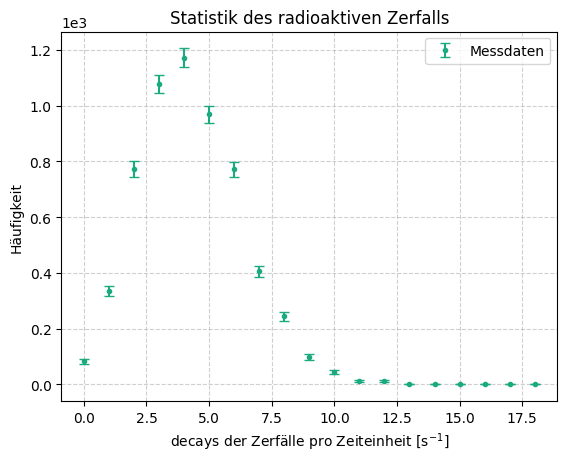

<Axes: title={'center': 'Statistik des radioaktiven Zerfalls'}, xlabel='decays der Zerfälle pro Zeiteinheit [$\\mathrm{s^{-1}}$]', ylabel='Häufigkeit'>

In [301]:
decays_2, counts_2 = np.loadtxt(data_file_2, unpack=True, delimiter=',', skiprows=4)
err_counts_2 = np.sqrt(counts_2)

# Plot
plt.errorbar(
    decays_2, 
    counts_2, 
    yerr = err_counts_2, 
    fmt = '.', 
    capsize = 3.5,
    label = 'Messdaten'
)

pap.plot_me('Statistik des radioaktiven Zerfalls', r'decays der Zerfälle pro Zeiteinheit [$\mathrm{s^{-1}}$]', 'Häufigkeit')


In [302]:
# Gauss fit
popt_gau_2, pcov_gau_2 = curve_fit(gaussian, decays_2[leftBound_2:rightBound_2], counts_2[leftBound_2:rightBound_2],
p0 = [2000, 5, 8], sigma = err_counts_2[leftBound_2:rightBound_2])

# Possion fit
popt_pos_2, pcov_pos_2 = curve_fit(poisson, decays_2[leftBound_2:rightBound_2], counts_2[leftBound_2:rightBound_2],
p0 = [2000, 5], sigma = err_counts_2[leftBound_2:rightBound_2])

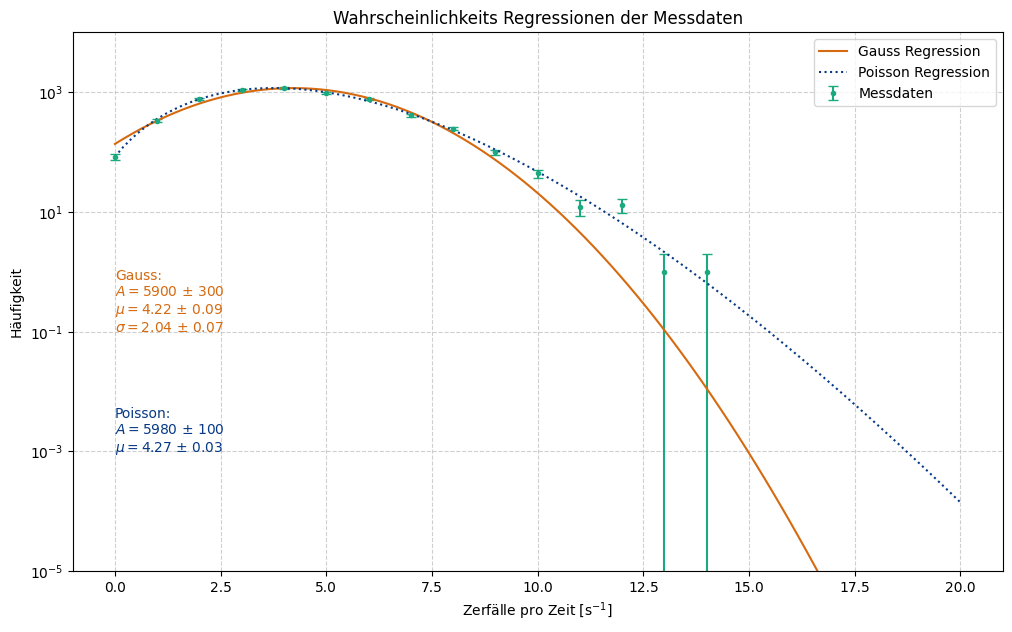

In [303]:
aufgabe = '3b'

plt.figure(figsize = (12, 7))
plt.ylim((1e-5, 1e4))
plt.yscale('log')

plt.errorbar(
    decays_2, 
    counts_2, 
    err_counts_2,
    fmt='.',
    capsize=3.5,
    label='Messdaten'
    )

# Regressions Funktionen
x = np.linspace(0, 20, 100)
plt.plot(
    x, 
    gaussian(x, *popt_gau_2), 
    label = 'Gauss Regression'
    )

plt.plot(
    x, 
    poisson(x, *popt_pos_2), 
    label = 'Poisson Regression',
    linestyle = ':'
    )


plt.text(0, 1e-1, 
        'Gauss:\n$A=$' 
        + pap.round_sig_digs(sqrt(pcov_gau_2[0][0]), popt_gau_2[0])[3] 
        + '\n' + r'$\mu=$'
        + pap.round_sig_digs(sqrt(pcov_gau_2[1][1]), popt_gau_2[1])[3] 
        + '\n' + r'$\sigma=$'
        + pap.round_sig_digs(sqrt(pcov_gau_2[2][2]), popt_gau_2[2])[3],
        color=c.ORANGE
        )

plt.text(0, 1e-3, 
        'Poisson:\n$A=$' 
        + pap.round_sig_digs(sqrt(pcov_pos_2[0][0]), popt_pos_2[0])[3] 
        + '\n' + r'$\mu=$'
        + pap.round_sig_digs(sqrt(pcov_pos_2[1][1]), popt_pos_2[1])[3],
        color=c.BLUE
        )


plt.title('Wahrscheinlichkeits Regressionen der Messdaten')
plt.xlabel(r'Zerfälle pro Zeit [$\mathrm{s^{-1}}$]')
plt.ylabel('Häufigkeit')
plt.savefig(f'{plt_save_folder}histo{aufgabe}.pdf')
plt.legend()
plt.show()

In [304]:
#Gauss:
chi2_gau_2 = np.sum((gaussian(decays_2[leftBound_2:rightBound_2], *popt_gau_2) - counts_2[leftBound_2:rightBound_2]) ** 2 / err_counts_2[leftBound_2:rightBound_2] ** 2)
dof_g = len(decays_2[leftBound_2:rightBound_2])- 3
chi2_red_g = chi2_gau_2 / dof_g
print("chi2_g=", chi2_gau_2)
print("chi2_red_g=",chi2_red_g)

#Poisson:
chi2_pos_2 = np.sum((poisson(decays_2[leftBound_2:rightBound_2], *popt_pos_2) - counts_2[leftBound_2:rightBound_2]) ** 2 / err_counts_2[leftBound_2:rightBound_2] ** 2)
dof_p = len(decays_2[leftBound_2:rightBound_2]) - 2 # poisson hat nur 2 Parameter
chi2_red_pos_2 = chi2_pos_2 / dof_p
print("chi2_p=", chi2_pos_2)
print("chi2_red_p=",chi2_red_pos_2)

#Gauss:
prob_g = round(1 - chi2.cdf(chi2_gau_2, dof_g),4) * 100

#Poisson:
prob_p = round(1 - chi2.cdf(chi2_pos_2, dof_p),4) * 100

print(fr"Wahrscheinlichkeit Gauss = {prob_g}%")
print(fr"Wahrscheinlichkeit Poisson = {prob_p}%")

chi2_g= 128.15065070663144
chi2_red_g= 10.679220892219286
chi2_p= 19.631837944039678
chi2_red_p= 1.5101413803107444
Wahrscheinlichkeit Gauss = 0.0%
Wahrscheinlichkeit Poisson = 10.48%
